# GPS points — all sites
PyGMT map of GPS points from `gps_data_all_sites/`, colored by group.

Run with the **trav** conda env kernel (that's where pygmt is installed).

In [1]:
import glob, os
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Overlay geologic map (using .tif file) from:
## " Surficial geologic map of the Steamboat Springs 30' X 60' quadrangle, Grand, Jackson, and Routt Counties, Colorado"
### Madole, R.F., 1991
#### online image map: U.S. Geological Survey, Miscellaneous Investigations Series Map I-1825, scale 1:100,000
https://ngmdb.usgs.gov/ngm-bin/pdp/zui_viewer.pl?id=281

In [2]:
# Upload tif file for the 1991 steamboat 30' X 60' surficial geologic map
src = rasterio.open("geologic_background/geology_maps/USGS/USGS_I-1825_1.tif")

In [3]:
data_dir = 'gps_data_all_sites'
frames = []
for fp in sorted(glob.glob(os.path.join(data_dir, '*.csv'))):
    df = pd.read_csv(fp)
    df['group'] = os.path.splitext(os.path.basename(fp))[0]
    frames.append(df[['group', 'Latitude', 'Longitude']])
gps = pd.concat(frames, ignore_index=True).dropna(subset=['Latitude', 'Longitude'])
print(gps.groupby('group').size())
gps.head()

group
group2_nsseismic_GPS     7
group3_hh                2
group3_hh_expanded      17
group4_nsseismic_GPS    13
group5_nsseismic_GPS    11
dtype: int64


,group,Latitude,Longitude
0,group2_nsseismic_GPS,40.482064,-106.836369
1,group2_nsseismic_GPS,40.482110,-106.836637
2,group2_nsseismic_GPS,40.482146,-106.836920
3,group2_nsseismic_GPS,40.482182,-106.837208
4,group2_nsseismic_GPS,40.482236,-106.837479


NameError: name 'colors' is not defined

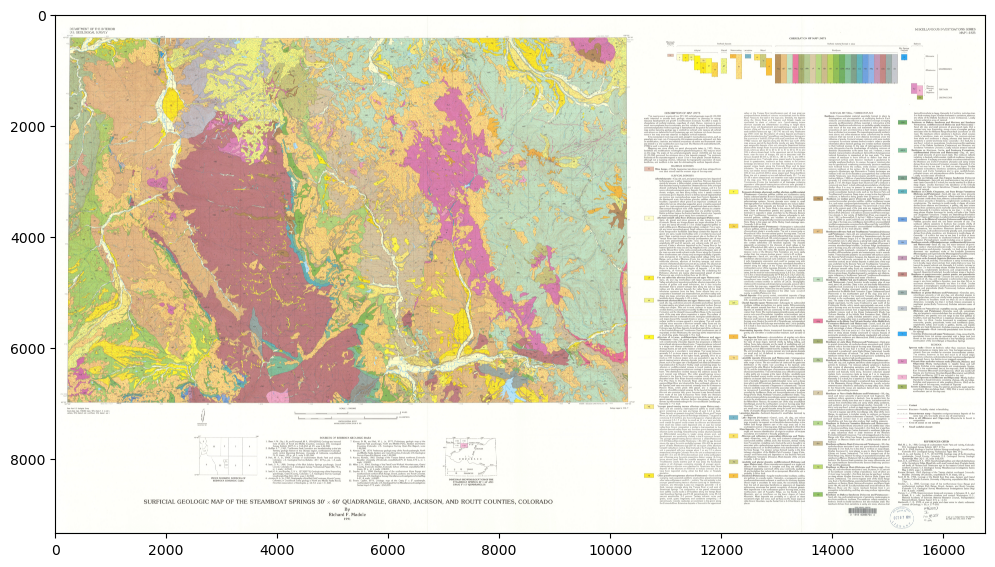

In [4]:
fig, ax = plt.subplots(figsize=(12, 8))

# plot the USGS map
show(src, ax=ax)

# Plot your survey lines
for color, (grp, sub) in zip(colors, gps.groupby('group')):
    sub = sub.sort_values('Latitude')
    ax.plot(
        sub['Longitude'], sub['Latitude'],
        color=color, linewidth=3.5, label=grp
    )


In [ ]:
ax.plot(sub['Longitude'], sub['Latitude'], ...)

In [ ]:
import io
import math
import requests
from PIL import Image


def _deg2num(lat_deg, lon_deg, zoom):
    lat_rad = math.radians(lat_deg)
    n_ = 2.0 ** zoom
    x = int((lon_deg + 180.0) / 360.0 * n_)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n_)
    return x, y


def _num2deg(x, y, zoom):
    n_ = 2.0 ** zoom
    lon = x / n_ * 360.0 - 180.0
    lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n_))))
    return lat, lon


def fetch_esri_imagery(west, south, east, north, zoom=18):
    """Mosaic Esri World Imagery XYZ tiles covering the bbox. Returns (PIL.Image, [w, e, s, n])."""
    x0, y1 = _deg2num(north, west, zoom)
    x1, y0 = _deg2num(south, east, zoom)
    xs = range(min(x0, x1), max(x0, x1) + 1)
    ys = range(min(y0, y1), max(y0, y1) + 1)
    mosaic = Image.new('RGB', (256 * len(xs), 256 * len(ys)))
    headers = {'User-Agent': 'Mozilla/5.0 (research notebook)'}
    for i, xt in enumerate(xs):
        for j, yt in enumerate(ys):
            tile_url = (
                'https://server.arcgisonline.com/ArcGIS/rest/services/'
                f'World_Imagery/MapServer/tile/{zoom}/{yt}/{xt}'
            )
            r = requests.get(tile_url, headers=headers, timeout=20)
            r.raise_for_status()
            mosaic.paste(Image.open(io.BytesIO(r.content)), (i * 256, j * 256))
    nw_lat, nw_lon = _num2deg(list(xs)[0], list(ys)[0], zoom)
    se_lat, se_lon = _num2deg(list(xs)[-1] + 1, list(ys)[-1] + 1, zoom)
    return mosaic, [nw_lon, se_lon, se_lat, nw_lat]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

pad = 0.0005
w = gps.Longitude.min() - pad
e = gps.Longitude.max() + pad
s = gps.Latitude.min() - pad
n = gps.Latitude.max() + pad

img, extent = fetch_esri_imagery(w, s, e, n, zoom=17)
aspect = 1.0 / np.cos(np.deg2rad((s + n) / 2))

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
ax.imshow(img, extent=extent, aspect=aspect, origin='upper')

colors = ['red', 'blue', 'lime', 'orange', 'magenta', 'cyan']
halo = [pe.Stroke(linewidth=6, foreground='white'), pe.Normal()]
for color, (grp, sub) in zip(colors, gps.groupby('group')):
    sub = sub.sort_values('Latitude')
    ax.plot(
        sub['Longitude'].to_numpy(),
        sub['Latitude'].to_numpy(),
        color=color,
        linewidth=3.5,
        solid_capstyle='round',
        path_effects=halo,
        label=grp,
        zorder=5,
    )

ax.set_xlim(w, e)
ax.set_ylim(s, n)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.ticklabel_format(useOffset=False, style='plain')
ax.legend(loc='upper right', framealpha=0.9)
plt.title('GPS Locations of NS Seismic Surveys')
plt.tight_layout()
plt.savefig('gps_map.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


g3 = gps[gps['group'] == 'group3_hh'].sort_values('Latitude').reset_index(drop=True)

# SE start (index 0) → NW end. Line is 0 m → 94 m.
g3_start_lat, g3_start_lon = g3.iloc[0]['Latitude'], g3.iloc[0]['Longitude']
g3_end_lat,   g3_end_lon   = g3.iloc[-1]['Latitude'], g3.iloc[-1]['Longitude']

g3_distances = np.arange(0, 95, 2)              # 0, 2, 4, ..., 94 m
t = g3_distances / 94.0
g3_lats = g3_start_lat + t * (g3_end_lat - g3_start_lat)
g3_lons = g3_start_lon + t * (g3_end_lon - g3_start_lon)

# Color rules:
#   - default: blue   (all 2 m dots)
#   - purple: any 2 m dot whose distance is a multiple of 6 (0, 6, 12, ..., 90 m)
#   - red:   the 18th 2 m dot (index 17, distance 34 m)
g3_colors = []
for i, d in enumerate(g3_distances):
    if i == 17:
        g3_colors.append('red')
    elif d % 6 == 0:
        g3_colors.append('hotpink')
    else:
        g3_colors.append('turquoise')

pad = 0.0002
w = g3_lons.min() - pad
e = g3_lons.max() + pad
s = g3_lats.min() - pad
n = g3_lats.max() + pad

img2, extent = fetch_esri_imagery(w, s, e, n, zoom=19)
aspect = 1.0 / np.cos(np.deg2rad((s + n) / 2))

fig, ax = plt.subplots(figsize=(12, 8), dpi=200)
ax.imshow(img2, extent=extent, aspect=aspect, origin='upper')

ax.scatter(
    g3_lons, g3_lats,
    c=g3_colors, s=45, edgecolor='black', linewidth=0.5,
    zorder=5,
)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='turquoise',
           markeredgecolor='black', markersize=8, label='2 m spacing'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='hotpink',
           markeredgecolor='black', markersize=8, label='every 6 m (from 0 m)'),
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor='red',
           markeredgecolor='black', markersize=8, label=f'18th 2 m dot ({g3_distances[17]} m)'),
]
ax.legend(handles=legend_handles, loc='upper right', framealpha=0.9)

ax.set_xlim(w, e)
ax.set_ylim(s, n)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.ticklabel_format(useOffset=False, style='plain')
plt.title('Group 3 Survey Line')
plt.tight_layout()
plt.show()

# Try Integrated code below (without running anything above)

from file:///C:/Users/emily/AppData/Local/Temp/5a53bfc5-19fd-49f5-b7ce-e4750405194f_USGS_I-1825.zip.94f/USGS_I-1825_1.tif.aux.xml :


<WKT>PROJCS["NAD_1983_UTM_Zone_13N",GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-105.0],PARAMETER["Scale_Factor",0.9996],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0],AUTHORITY["EPSG",26913]]</WKT>


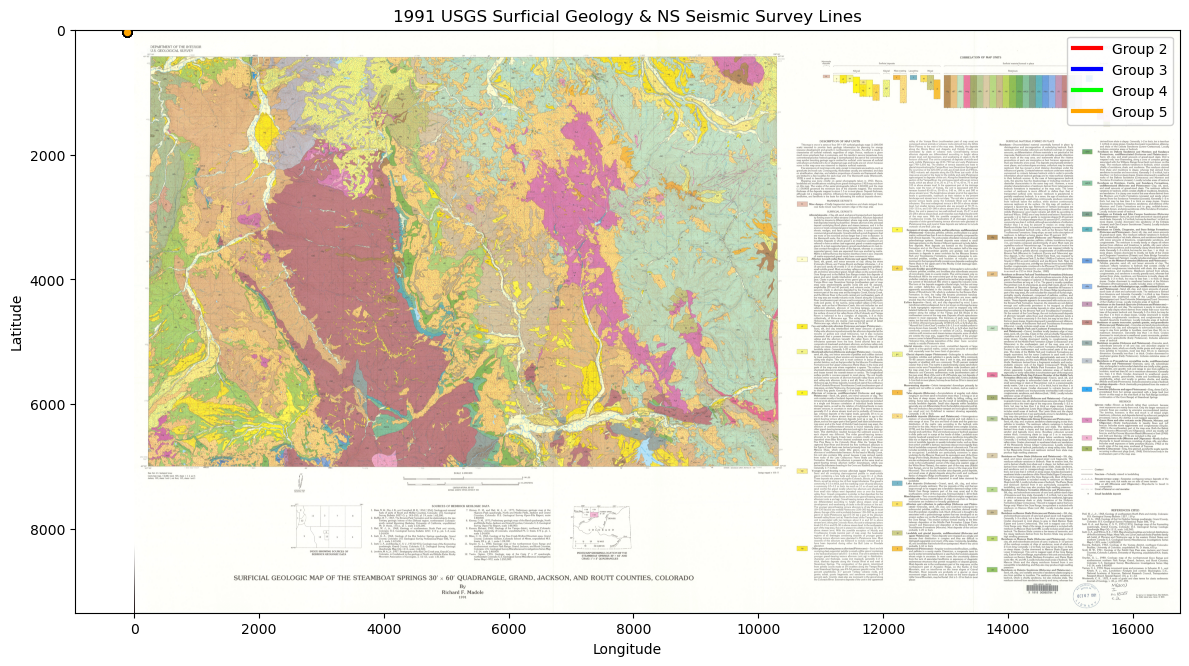

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from rasterio.crs import CRS
import numpy as np

# -----------------------------
# 1. Load the USGS GeoTIFF
# -----------------------------
tif_path = "geologic_background/geology_maps/USGS/USGS_I-1825_1.tif"
src = rasterio.open(tif_path)

# with src as source:
#     # Set the CRS using an EPSG code (EPSG:26913)
#     source.crs = CRS.from_epsg(26913)

# -----------------------------
# 2. Load all survey CSV files
# -----------------------------
groups = {
    "Group 2": pd.read_csv("gps_data_all_sites/group2_nsseismic_GPS.csv"),
    "Group 3": pd.read_csv("gps_data_all_sites/group3_hh.csv"),
    "Group 4": pd.read_csv("gps_data_all_sites/group4_nsseismic_GPS.csv"),
    "Group 5": pd.read_csv("gps_data_all_sites/group5_nsseismic_GPS.csv")
}

# -----------------------------
# 3. Create the plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the USGS geology raster
show(src, ax=ax)

# Colors for each group
colors = {
    "Group 2": "red",
    "Group 3": "blue",
    "Group 4": "lime",
    "Group 5": "orange"
}

# -----------------------------
# 4. Plot each survey line
# -----------------------------
for name, df in groups.items():
    df_sorted = df.sort_values("Latitude")
    ax.plot(
        df_sorted["Longitude"],
        df_sorted["Latitude"],
        color=colors[name],
        linewidth=3,
        label=name,
        zorder=10
    )
    ax.scatter(
        df_sorted["Longitude"],
        df_sorted["Latitude"],
        color=colors[name],
        edgecolor="black",
        s=40,
        zorder=11
    )

# -----------------------------
# 5. Optional: Add test hole locations
# -----------------------------
# Uncomment when you have the CSV
# holes = pd.read_csv("test_holes.csv")
# ax.scatter(
#     holes["Longitude"], holes["Latitude"],
#     c="yellow", edgecolor="black", s=80, zorder=20, label="Test Holes"
# )

# -----------------------------
# 6. Formatting
# -----------------------------
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("1991 USGS Surficial Geology & NS Seismic Survey Lines")
ax.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()


In [7]:
print(src.crs)

None


In [4]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import from_bounds, Window
from rasterio.plot import plotting_extent
from pyproj import Transformer


# ============================================================
# 1. FILE PATHS
# ============================================================

tif_path = "geologic_background/geology_maps/USGS/USGS_I-1825_1.tif"
gps_dir = "gps_data_all_sites"

# Optional drill-hole file.
# Change this path if your drill-hole file has a different name/location.
drill_hole_path = "drill_holes.csv"   # or "test_holes.csv"


# ============================================================
# 2. LOAD GPS SURVEY POINTS
# ============================================================

frames = []

for fp in sorted(glob.glob(os.path.join(gps_dir, "*.csv"))):
    df = pd.read_csv(fp)

    # Keep only rows with valid coordinates
    df = df.dropna(subset=["Latitude", "Longitude"]).copy()

    # Add group name from filename
    df["group"] = Path(fp).stem

    frames.append(df[["group", "Latitude", "Longitude"]])

gps = pd.concat(frames, ignore_index=True)

print("GPS groups:")
print(gps.groupby("group").size())


# ============================================================
# 3. LOAD DRILL HOLES, IF FILE EXISTS
# ============================================================

holes = None

if Path(drill_hole_path).exists():
    holes = pd.read_csv(drill_hole_path)
    holes = holes.dropna(subset=["Latitude", "Longitude"]).copy()

    # Optional: if your drill-hole file has a name/id column, change this.
    if "Name" not in holes.columns:
        holes["Name"] = [f"Hole {i+1}" for i in range(len(holes))]

    print(f"\nLoaded {len(holes)} drill holes from {drill_hole_path}")

else:
    print(f"\nNo drill-hole file found at: {drill_hole_path}")
    print("Continuing with GPS survey points only.")


# ============================================================
# 4. OPEN GEOLOGIC MAP AND CHECK CRS
# ============================================================

src = rasterio.open(tif_path)

print("\nGeoTIFF CRS:")
print(src.crs)

print("\nGeoTIFF bounds:")
print(src.bounds)

if src.crs is None:
    raise ValueError(
        "This GeoTIFF does not have CRS/georeferencing information. "
        "It cannot be automatically aligned to GPS coordinates until it is georeferenced."
    )


# ============================================================
# 5. TRANSFORM GPS/DRILL-HOLE COORDS INTO GEOLOGIC MAP CRS
# ============================================================

# GPS coordinates are longitude/latitude, usually EPSG:4326.
gps_crs = "EPSG:4326"
map_crs = src.crs

transformer = Transformer.from_crs(gps_crs, map_crs, always_xy=True)

gps["x_map"], gps["y_map"] = transformer.transform(
    gps["Longitude"].to_numpy(),
    gps["Latitude"].to_numpy()
)

if holes is not None:
    holes["x_map"], holes["y_map"] = transformer.transform(
        holes["Longitude"].to_numpy(),
        holes["Latitude"].to_numpy()
    )


# ============================================================
# 6. BUILD ZOOM BOUNDS AROUND GPS + DRILL HOLES
# ============================================================

all_x = list(gps["x_map"])
all_y = list(gps["y_map"])

if holes is not None:
    all_x += list(holes["x_map"])
    all_y += list(holes["y_map"])

minx, maxx = min(all_x), max(all_x)
miny, maxy = min(all_y), max(all_y)

width = maxx - minx
height = maxy - miny

# Padding around survey area.
# If map CRS is projected, this is usually meters.
# Increase this if you want more surrounding geology.
if map_crs.is_geographic:
    pad = max(width, height) * 0.75
    pad = max(pad, 0.002)      # degrees
else:
    pad = max(width, height) * 0.75
    pad = max(pad, 150)        # meters

west = minx - pad
east = maxx + pad
south = miny - pad
north = maxy + pad

print("\nZoom bounds in map CRS:")
print("west/east:", west, east)
print("south/north:", south, north)


# ============================================================
# 7. CROP GEOLOGIC MAP TO ZOOM BOUNDS
# ============================================================

window = from_bounds(
    west,
    south,
    east,
    north,
    transform=src.transform
)

# Clip the requested window to the actual raster extent
full_window = Window(0, 0, src.width, src.height)
window = window.intersection(full_window)
window = window.round_offsets().round_lengths()

geology_crop = src.read(window=window)
crop_transform = src.window_transform(window)

extent = plotting_extent(geology_crop, transform=crop_transform)

print("\nCropped raster shape:")
print(geology_crop.shape)


# ============================================================
# 8. PREPARE RASTER IMAGE FOR PLOTTING
# ============================================================

# Most scanned geologic maps are RGB or RGBA.
if geology_crop.shape[0] >= 3:
    img = np.moveaxis(geology_crop[:3], 0, -1)

    # If not uint8, normalize for display
    if img.dtype != np.uint8:
        img = img.astype(float)
        lo, hi = np.nanpercentile(img, [2, 98])
        img = np.clip((img - lo) / (hi - lo), 0, 1)

else:
    img = geology_crop[0]


# ============================================================
# 9. PLOT CROPPED GEOLOGIC MAP + SURVEY LINES + DRILL HOLES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

ax.imshow(
    img,
    extent=extent,
    origin="upper"
)

colors = {
    "group2_nsseismic_GPS": "red",
    "group3_hh": "blue",
    "group4_nsseismic_GPS": "lime",
    "group5_nsseismic_GPS": "orange",
}

for group_name, sub in gps.groupby("group"):
    # Sorting by latitude is okay for mostly N-S lines.
    # If a line plots strangely, remove this sort and use original CSV order.
    sub = sub.sort_values("Latitude")

    color = colors.get(group_name, None)

    ax.plot(
        sub["x_map"],
        sub["y_map"],
        linewidth=3,
        color=color,
        label=group_name,
        zorder=10
    )

    ax.scatter(
        sub["x_map"],
        sub["y_map"],
        s=35,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        zorder=11
    )


# Plot drill holes if loaded
if holes is not None:
    ax.scatter(
        holes["x_map"],
        holes["y_map"],
        marker="*",
        s=180,
        color="yellow",
        edgecolor="black",
        linewidth=1.0,
        label="Drill holes",
        zorder=20
    )

    for _, row in holes.iterrows():
        ax.text(
            row["x_map"],
            row["y_map"],
            f" {row['Name']}",
            fontsize=9,
            weight="bold",
            zorder=21
        )


ax.set_xlim(west, east)
ax.set_ylim(south, north)

ax.set_title("Cropped USGS Surficial Geology Map with Survey Lines and Drill Holes")
ax.set_xlabel(f"X coordinate ({map_crs})")
ax.set_ylabel(f"Y coordinate ({map_crs})")
ax.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.savefig("cropped_geologic_map_with_survey_lines.png", dpi=300, bbox_inches="tight")
plt.show()

ImportError: DLL load failed while importing _warp: The specified procedure could not be found.